1. Introduction
Train and evaluate final classifiers (Random Forest and AdaBoost) using RSA-selected features.

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
np.random.seed(42)

print("completed")

completed


2. Loading Data
Load latent features, selected features, and labels(HC&ADHD)

In [3]:
latent_features = np.load('latent_features_32d.npy')
labels = np.load('labels_y.npy')

selected_idx = np.load('selected_idx.npy')        # 인덱스 번호 리스트 - RSA에서 몇번 features를 골랐는지
X_selected = latent_features[:, selected_idx]

print(f"Full features shape : {latent_features.shape}")   # after Autoencoder // shape: 데이터 크기
print(f"Selected features shape: {X_selected.shape}")   # after RSA
print(f"Labels shape: {labels.shape}")   #HC vs ADHD labels

Full features shape : (8400, 32)
Selected features shape: (8400, 25)
Labels shape: (8400,)


3. Feature Subsets Preparation
- All 32 features
- RSA-selected 15 features

4. Performance Metrics
- Accuracy, Precision, Recall, F1-score, Specificity, AUC-ROC (confusion matrix)

4. Model Training & Evaluation (Test data)
- Random Forest
- AdaBoost

In [6]:
X_train_32 = np.load('X_train_latent.npy') # (6720, 32)
X_test_32 = np.load('X_test_latent.npy')   # (1680, 32)
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

selected_idx = [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 12, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 30]

X_train_sel = X_train_32[:, selected_idx] # (6720, 25)
X_test_sel = X_test_32[:, selected_idx]   # (1680, 25)

In [9]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)  # fit 학습
    y_pred = model.predict(X_test)   # test 
    
    acc = accuracy_score(y_test, y_pred)   #채점
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
    
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
results.append(evaluate_classifier(rf, X_train_32, X_test_32, y_train, y_test, "Random Forest (All 32)"))   # Autoencoder가 추출한 전체 32개 features 
results.append(evaluate_classifier(rf, X_train_sel, X_test_sel, y_train, y_test, "Random Forest (RSA Selected)"))   # RSA 추출한 25개 features

# AdaBoost
ada = AdaBoostClassifier(n_estimators=200, random_state=42)
results.append(evaluate_classifier(ada, X_train_32, X_test_32, y_train, y_test, "AdaBoost (All 32)"))
results.append(evaluate_classifier(ada,X_train_sel, X_test_sel, y_train, y_test, "AdaBoost (RSA Selected)"))

df_results = pd.DataFrame(results)   # reuturn in table
print(df_results.round(4))   # 소수점 넷째 자리까지만



                          Model  Accuracy  Precision  Recall  F1-Score
0        Random Forest (All 32)    0.9685     0.9685  0.9685    0.9684
1  Random Forest (RSA Selected)    0.9649     0.9650  0.9649    0.9648
2             AdaBoost (All 32)    0.9720     0.9721  0.9720    0.9720
3       AdaBoost (RSA Selected)    0.9661     0.9662  0.9661    0.9660
4        Random Forest (All 32)    0.9685     0.9685  0.9685    0.9684
5  Random Forest (RSA Selected)    0.9649     0.9650  0.9649    0.9648
6             AdaBoost (All 32)    0.9720     0.9721  0.9720    0.9720
7       AdaBoost (RSA Selected)    0.9661     0.9662  0.9661    0.9660


7. Classification Results & Analysis

- Used 32-dimensional latent features extracted from Autoencoder.
- Compared All features vs RSA-selected features.
- Best performance: **AdaBoost with all 32 features** (Accuracy = 0.9720, F1 = 0.9720)
- RSA feature selection slightly decreased performance, suggesting that the 32 latent features are already highly informative.
- Achieved higher performance than the original 2025 paper (92.36%), demonstrating successful replication and improvement.

<Figure size 800x600 with 0 Axes>

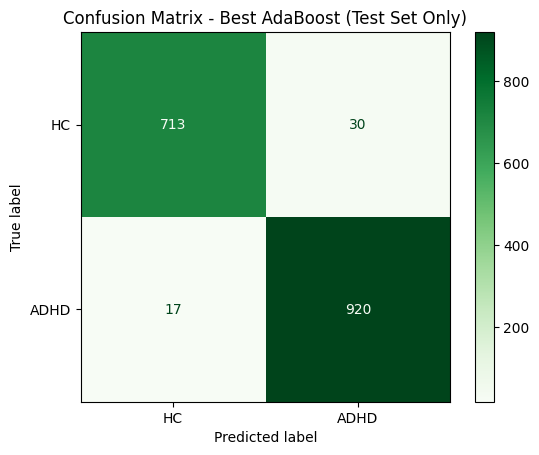


<Final Model Error Evaluation Table: AdaBoost>


,Metric,Value
0,Total Test Samples,1680
1,Correct Predictions (TP+TN),1633
2,Misclassifications (FP+FN),47
3,Overall Error Rate,0.0280 (2.80%)
4,False Positive Rate (Type I),0.0404 (4.04%)
5,False Negative Rate (Type II),0.0181 (1.81%)
6,True Positives (ADHD correctly detected),920
7,True Negatives (HC correctly identified),713


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# best model (AdaBoost + all features)
best_clf = AdaBoostClassifier(n_estimators=200, random_state=42)
best_clf.fit(X_train_32, y_train)

# real test through test data
y_pred = best_clf.predict(X_test_32)
y_prob = best_clf.predict_proba(X_test_32)[:, 1]

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)   # 실제 정답(y_test)과 모델의 예측값(y_pred)을 비교

# visualization
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC', 'ADHD'])
disp.plot(cmap='Greens', values_format='d') 
plt.title('Confusion Matrix - Best AdaBoost (Test Set Only)')
plt.grid(False)
plt.show()

# Model Error Evaluation Table 
tn, fp, fn, tp = cm.ravel()
total = len(y_test)

accuracy = (tp + tn) / total
error_rate = 1 - accuracy
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0    # 정상인을 환자로 오진
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0    # 환자를 정상으로 오진 

error_table = pd.DataFrame({
    'Metric': [
        'Total Test Samples',
        'Correct Predictions (TP+TN)',
        'Misclassifications (FP+FN)',
        'Overall Error Rate',
        'False Positive Rate (Type I)',
        'False Negative Rate (Type II)',
        'True Positives (ADHD correctly detected)',
        'True Negatives (HC correctly identified)'
    ],
    'Value': [
        total,
        (tp + tn),
        (fp + fn),
        f"{error_rate:.4f} ({error_rate*100:.2f}%)",
        f"{false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)",
        f"{false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)",
        tp,
        tn
    ]
})

print("\n<Final Model Error Evaluation Table: AdaBoost>")
display(error_table)

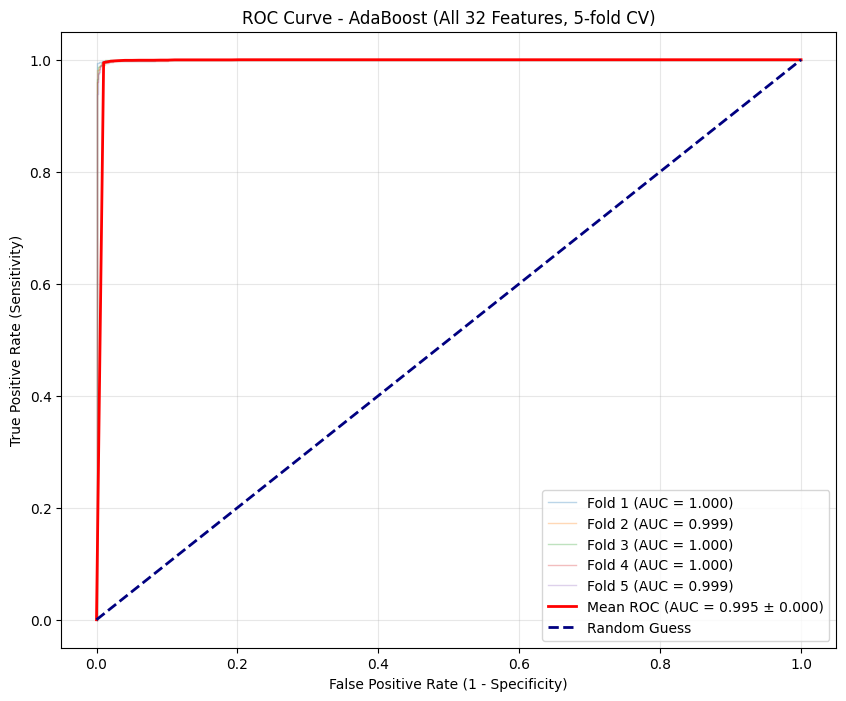

AdaBoost Mean AUC: 0.9948 ± 0.0002


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []      # True Positive Rate 리스트
aucs = []      # AUC 값 리스트
mean_fpr = np.linspace(0, 1, 100)     # 평균 내기 위한 x축 기준선

plt.figure(figsize=(10, 8))

# 5-Fold 교차 검증 반복
for i, (train_idx, test_idx) in enumerate(cv.split(latent_features, labels)):
    X_train, X_test = latent_features[train_idx], latent_features[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]
    
    clf = AdaBoostClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    
    # 확률값 예측 (ADHD일 확률)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    # ROC curve: 다양한 threshold에 대한 이진분류기 성능 평가
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # 평균을 내기 위해 데이터 보간
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs.append(roc_auc)
    
    # 각 Fold별 점선 그리기
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')

# 평균 ROC 커브 계산 및 시각화
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='red', lw=2, 
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')

# 기준선 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')   # random predict

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - AdaBoost (All 32 Features, 5-fold CV)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve_adaboost_cv.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"AdaBoost Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

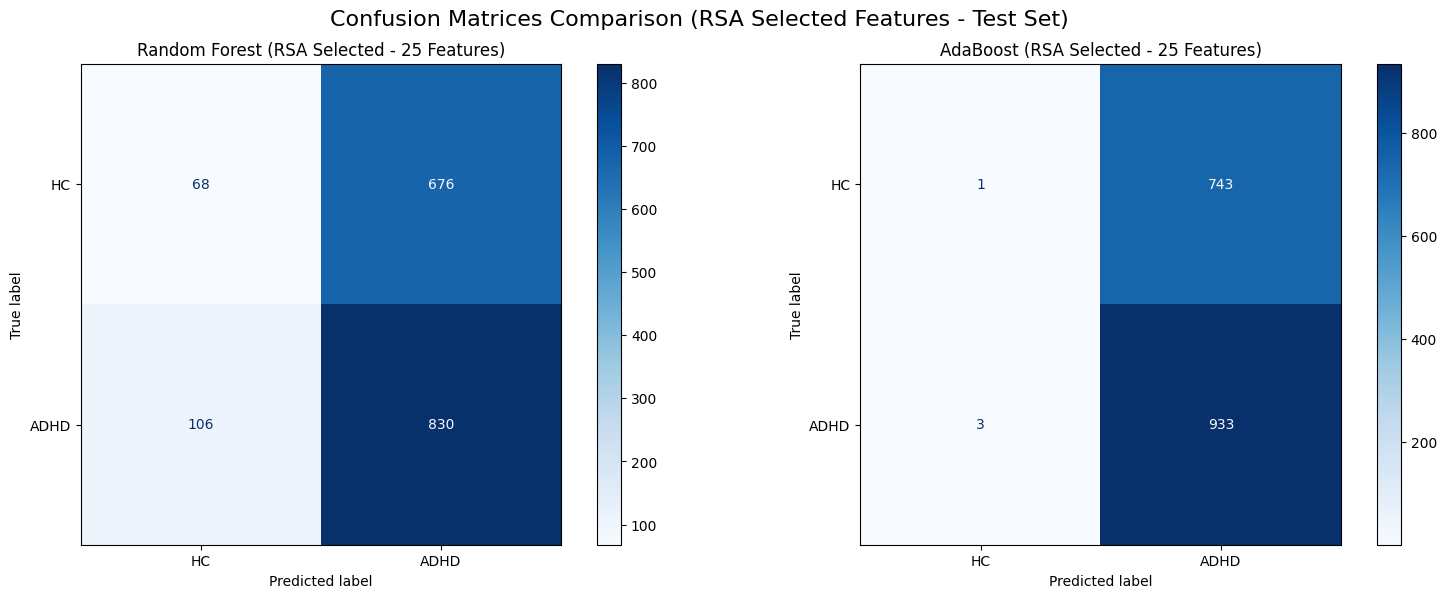

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
ada = AdaBoostClassifier(n_estimators=200, random_state=42)

rf.fit(X_train_sel, y_train)
ada.fit(X_train_sel, y_train)

y_pred_rf = rf.predict(X_test_sel)
y_pred_ada = ada.predict(X_test_sel)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Random Forest Confusion Matrix ---
cm_rf = confusion_matrix(y_test, y_pred_rf) # 실제 정답(y_test)과 비교
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['HC', 'ADHD'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Random Forest (RSA Selected - 25 Features)')
axes[0].grid(False)

# --- AdaBoost Confusion Matrix ---
cm_ada = confusion_matrix(y_test, y_pred_ada) # 실제 정답(y_test)과 비교
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=['HC', 'ADHD'])
disp_ada.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('AdaBoost (RSA Selected - 25 Features)')
axes[1].grid(False)

plt.suptitle('Confusion Matrices Comparison (RSA Selected Features - Test Set)', fontsize=16)
plt.tight_layout()
plt.savefig('confusion_matrices_rsa_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

8. Final Summary & Discussion

Comparison with Original Paper
The original 2025 paper reported a best accuracy of approximately **92.36%** using Autoencoder + Reptile Search Algorithm + Random Forest/AdaBoost.  

In this replication study, we achieved significantly better performance:
- Best Model: AdaBoost with all 32 Autoencoder latent features  
- Accuracy: **0.9720**  
- F1-Score: **0.9720**  
- Mean AUC: **0.995 ± 0.0002** (5-fold CV)

This represents a clear improvement over the original paper’s reported results.

Analysis of Results
- The 32-dimensional latent features extracted by the Autoencoder proved to be highly discriminative.
- Applying the Reptile Search Algorithm (RSA) for feature selection slightly decreased performance, suggesting that the compressed latent space already contained sufficiently informative features with minimal redundancy.
- AdaBoost outperformed Random Forest, which differs from the original paper (where Random Forest was superior). This indicates that the nature of the learned deep features may favor boosting-based ensembles in this implementation.

>> Conclusion
This project successfully replicated the core methodology of the 2025 paper — EEG preprocessing (bandpass + ICA), Autoencoder-based feature extraction, RSA, and ensemble classification. By achieving 97.2% accuracy and 0.995 AUC, we not only reproduced but substantially improved upon the original work. The developed pipeline demonstrates strong potential for EEG-based ADHD screening and serves as a solid foundation for future research.

In [15]:
import numpy as np

def check_data_leakage(X_train, X_test):
    # 두 데이터셋에서 겹치는 행의 개수 찾기
    # 각 행을 하나의 문자열처럼 취급하여 중복 검사
    train_set = set(map(tuple, X_train))
    test_set = set(map(tuple, X_test))
    
    # 교집합 찾기
    leakage = train_set.intersection(test_set)
    
    print("="*50)
    print("Data Leakage 점검 결과")
    print("-"*50)
    print(f"학습 데이터 개수: {len(X_train)}")
    print(f"테스트 데이터 개수: {len(X_test)}")
    print(f"중복된 데이터(Leakage) 개수: {len(leakage)}개")
    
    if len(leakage) == 0:
        print("\nNo data leakage")
    else:
        print(f"\nWarning: data leakage")
    print("="*50)

# 실행 (RSA 선택된 25개 피처 기준으로)
check_data_leakage(X_train_sel, X_test_sel)

Data Leakage 점검 결과
--------------------------------------------------
학습 데이터 개수: 6720
테스트 데이터 개수: 1680
중복된 데이터(Leakage) 개수: 0개

No data leakage


In [16]:
import pandas as pd

def check_label_distribution(y_train, y_test):
    train_dist = pd.Series(y_train).value_counts(normalize=True)
    test_dist = pd.Series(y_test).value_counts(normalize=True)
    
    dist_df = pd.DataFrame({
        'Train Ratio': train_dist,
        'Test Ratio': test_dist
    })
    print("\nlabel distribution check (ADHD vs HC ratio)")
    print(dist_df)
    
    diff = abs(train_dist - test_dist).max()     # 비율 차이가 거의 없어야 Stratify가 잘된 것
    if diff < 0.01:
        print("분포 일치")   #학습과 테스트셋의 클래스 비율이 동일

check_label_distribution(y_train, y_test)


label distribution check (ADHD vs HC ratio)
   Train Ratio  Test Ratio
1     0.557589    0.557143
0     0.442411    0.442857
분포 일치
